In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats

df = pd.read_csv("C:/Users/15177459/Desktop/Bopha/Personality and selection of companies (DSSA)_April 20, 2026_04.35.csv", skiprows= [1, 2])
print(len(df))

309


# Cleanup

In [115]:
new_columns = {
    'Comp A Exploit_Exploit': "Comp_B_Explor_Exploit",
    'Comp A Exploit_Ins': "Comp_B_Explor_Ins",
    'Comp A Exploit_Soci': "Comp_B_Explor_Soci",
    'Comp A Exploit_Obs': "Comp_B_Explor_Obs",
    'Comp A Exploit_Duty': "Comp_B_Explor_Duty",
    'Comp A Exploit_Explor': "Comp_B_Explor_Explor",

    "Comp_B_Explor_Exploit": "Comp_B_Insec_Exploit", 
    "Comp_B_Explor_Ins": "Comp_B_Insec_Ins",
    "Comp_B_Explor_Soci": "Comp_B_Insec_Soci",
    "Comp_B_Explor_Obs": "Comp_B_Insec_Obs",
    "Comp_B_Explor_Duty": "Comp_B_Insec_Duty",
    "Comp_B_Explor_Explor": "Comp_B_Insec_Explor"

}

df = df.rename(columns=new_columns)

print(df.columns.tolist())
print(df.head())


['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress', 'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName', 'RecipientEmail', 'ExternalReference', 'LocationLatitude', 'LocationLongitude', 'DistributionChannel', 'UserLanguage', 'Consent_form', 'Recruitment', 'SONA_ID', 'Gender', 'Gender_3_TEXT', 'Age', 'Student', 'Year_of_study', 'Year_of_study_6_TEXT', 'Type_study', 'Type_study_4_TEXT', 'Education', 'Work_exp', 'employment', 'Weekly_hrs', 'Employed_Industry', 'Employed_Industry_21_TEXT', 'employed_Occupation', 'employed_Occupation_24_TEXT', 'Desired_industry', 'Desired_industry_21_TEXT', 'Desired_occupation', 'Desired_occupation_24_TEXT', 'Employees_nr', 'Twolvl_company_1', 'Threelvl_company_1', 'Fivelvl_company_1', 'Sevenlvl_company_1', 'Unemployed_industry', 'Unemployed_industry_21_TEXT', 'Unemployed_occupatio', 'Unemployed_occupatio_24_TEXT', 'Oaesa1', 'Corga3', 'Aforg1', 'Xsses1', 'Efear1', 'Hsinc4', 'Oinqu1', 'Cdili2', 

In [116]:
# Cleaning Data

bad_respondents = [
    "R_87BZLd8akobbh8U",
    "R_2bNJxCYf4hmuet0",
    "R_8dBhGl7XMl4jjIl"
]

df = df[
    (df["Finished"] != "0") &
    (~df["ResponseId"].isin(bad_respondents))
].copy()

print(len(df))
print("Unfinished rows:", (df["Finished"] == 0).sum())
print("Bad respondent rows:", df["ResponseId"].isin(bad_respondents).sum())

unique_list = sorted(df["Age"].dropna().unique().tolist())
print(unique_list)

190
Unfinished rows: 0
Bad respondent rows: 0
['18', '19', '20', '21', '22', '23', '24', '25', '26', '28', '30', '31', '36', '37', '46', '48', '49', '50', '51', '55', '58', '60', '61', '62', '70', '{"ImportId":"QID57_TEXT"}']


# Descriptives

In [117]:

des_cols =["Age", "Gender", "employment"]

df = df[~df['Age'].astype(str).str.contains('ImportId')]

# Now convert your columns back to numbers so you can sort them properly
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Gender'] = pd.to_numeric(df['Gender'], errors='coerce')
df['employment'] = pd.to_numeric(df['employment'], errors='coerce')


for i in des_cols:
    # Drop NaNs, get unique values, convert to list, and sort
    unique_list = sorted(df[i].dropna().unique().tolist())
    print(i, ":", unique_list)

Age : [18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 30, 31, 36, 37, 46, 48, 49, 50, 51, 55, 58, 60, 61, 62, 70]
Gender : [1, 2]
employment : [22, 23]


In [118]:
age_descriptives = df[['Age']].describe().T[['mean', 'std', 'min', 'max']]
print("--- Age Descriptives ---")
print(age_descriptives)


--- Age Descriptives ---
         mean       std   min   max
Age  23.68254  9.870694  18.0  70.0


In [119]:
for col in ['Gender', 'employment']:
    print(f"\n--- {col.title()} Shares ---")
    
    # Calculate counts and percentages
    counts = df[col].value_counts()
    shares = df[col].value_counts(normalize=True) * 100
    
    # Combine into a clean table
    summary_table = pd.DataFrame({'Count': counts, 'Percentage (%)': shares})
    print(summary_table.round(2))


--- Gender Shares ---
        Count  Percentage (%)
Gender                       
2         148           78.31
1          41           21.69

--- Employment Shares ---
            Count  Percentage (%)
employment                       
22            146           77.25
23             43           22.75


# Openness vs Exploration

In [120]:
columns_to_reverse = ["Oaesa1", "Oinqu8", "Ocrea8", "Ounco2", "Ounco8"]

for i in columns_to_reverse:
    print(df[i].head)

<bound method NDFrame.head of 1      3
2      2
3      4
4      3
5      1
      ..
291    1
293    4
295    5
299    1
307    2
Name: Oaesa1, Length: 189, dtype: str>
<bound method NDFrame.head of 1      2
2      4
3      2
4      1
5      1
      ..
291    2
293    4
295    1
299    4
307    4
Name: Oinqu8, Length: 189, dtype: str>
<bound method NDFrame.head of 1      4
2      3
3      4
4      1
5      4
      ..
291    1
293    2
295    2
299    1
307    5
Name: Ocrea8, Length: 189, dtype: str>
<bound method NDFrame.head of 1      1
2      2
3      2
4      5
5      2
      ..
291    1
293    3
295    2
299    1
307    2
Name: Ounco2, Length: 189, dtype: str>
<bound method NDFrame.head of 1      4
2      4
3      2
4      2
5      2
      ..
291    1
293    4
295    5
299    1
307    3
Name: Ounco8, Length: 189, dtype: str>


In [121]:
# Recode Opennes columns

reverse_map = {
    "1":5,
    "2":4,
    "3":3,
    "4":2,
    "5":1
}

columns_to_reverse = ["Oaesa1", "Oinqu8", "Ocrea8", "Ounco2", "Ounco8"]

for i in columns_to_reverse:
    df[i] = df[i].map(reverse_map)
    print(df[i].head)

<bound method NDFrame.head of 1      3
2      4
3      2
4      3
5      5
      ..
291    5
293    2
295    1
299    5
307    4
Name: Oaesa1, Length: 189, dtype: int64>
<bound method NDFrame.head of 1      4
2      2
3      4
4      5
5      5
      ..
291    4
293    2
295    5
299    2
307    2
Name: Oinqu8, Length: 189, dtype: int64>
<bound method NDFrame.head of 1      2
2      3
3      2
4      5
5      2
      ..
291    5
293    4
295    4
299    5
307    1
Name: Ocrea8, Length: 189, dtype: int64>
<bound method NDFrame.head of 1      5
2      4
3      4
4      1
5      4
      ..
291    5
293    3
295    4
299    5
307    4
Name: Ounco2, Length: 189, dtype: int64>
<bound method NDFrame.head of 1      2
2      2
3      4
4      4
5      4
      ..
291    5
293    2
295    1
299    5
307    3
Name: Ounco8, Length: 189, dtype: int64>


In [122]:
# Openness Average

openness_items = ['Oaesa1', 'Oinqu1', 'Ocrea6', 'Oaesa4', 'Oinqu8', 'Ocrea7', 'Ounco2', 'Ounco5', 'Ocrea8', 'Ounco8']

dic_scores = {}

for i in openness_items:
    df[i] = pd.to_numeric(df[i], errors="coerce")
    dic_scores[i] = df[i].mean()

print("Average scores by item:")
print("-" * 30)

for item, score in dic_scores.items():
    print(f"{item}: {score:.2f}")

avg = 0
for keys, values in dic_scores.items():
    avg += values

print(f"Composite Average = {avg/(len(openness_items)): .2f}")

Average scores by item:
------------------------------
Oaesa1: 3.43
Oinqu1: 3.26
Ocrea6: 3.59
Oaesa4: 3.33
Oinqu8: 2.98
Ocrea7: 3.52
Ounco2: 3.64
Ounco5: 3.47
Ocrea8: 3.22
Ounco8: 3.52
Composite Average =  3.39


In [123]:

# 1. Force columns to numeric first so .map() or .dropna() works cleanly
df["Explor_selection"] = (
    df["Explor_selection"].astype(str).map({"0": 1, "1": 0})
)
df["Explor_sel_rating"] = (
    df["Explor_sel_rating"]
    .astype(str)
    .map({"6": 1, "5": 2, "4": 3, "3": 4, "2": 5, "1": 6})
)
df["Explor_sel_rating2_1"] = pd.to_numeric(
    df["Explor_sel_rating2_1"], errors="coerce"
)

# Convert openness items to numeric too
for col in openness_items:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================
# 2. DROP MISSING VALUES (Row-wise for your target columns)
# ==========================================
# This drops rows ONLY if they have a missing value in your core variables
analysis_cols = (
    ["Explor_selection", "Explor_sel_rating", "Explor_sel_rating2_1"]
    + openness_items
)
df = df.dropna(subset=analysis_cols)

# ==========================================
# 3. RUN CALCULATIONS (Safe from NaN issues now!)
# ==========================================

# Z-scores
df["Explor_selection_z"] = (
    df["Explor_selection"] - df["Explor_selection"].mean()
) / df["Explor_selection"].std()
df["Explor_sel_rating_z"] = (
    df["Explor_sel_rating"] - df["Explor_sel_rating"].mean()
) / df["Explor_sel_rating"].std()
df["Explor_sel_rating2_z"] = (
    df["Explor_sel_rating2_1"] - df["Explor_sel_rating2_1"].mean()
) / df["Explor_sel_rating2_1"].std()

# Composites
df["Exploration_Composite_Score"] = df[
    ["Explor_selection_z", "Explor_sel_rating_z", "Explor_sel_rating2_z"]
].mean(axis=1)
df["Openness_Average"] = df[openness_items].mean(axis=1)

# ==========================================
# 4. PREVIEWS
# ==========================================
print("\nPreview Exploration Scores:")
print(
    df[
        [
            "Explor_selection",
            "Explor_sel_rating",
            "Explor_sel_rating2_1",
            "Exploration_Composite_Score",
        ]
    ].head()
)

print("\nPreview Openness Scores:")
print(df[openness_items + ["Openness_Average"]].head())


Preview Exploration Scores:
   Explor_selection  Explor_sel_rating  Explor_sel_rating2_1  \
1                 1                  6                    12   
2                 0                  2                    74   
3                 1                  5                    19   
4                 1                  5                    10   
5                 1                  5                    10   

   Exploration_Composite_Score  
1                     0.318400  
2                    -0.613871  
3                     0.160464  
4                     0.039202  
5                     0.039202  

Preview Openness Scores:
   Oaesa1  Oinqu1  Ocrea6  Oaesa4  Oinqu8  Ocrea7  Ounco2  Ounco5  Ocrea8  \
1       3       3       4       3       4       2       5       4       2   
2       4       2       4       5       2       3       4       3       3   
3       2       4       4       4       4       2       4       3       2   
4       3       2       4       3       5       4     

=== OLS REGRESSION SUMMARY ===
                                 OLS Regression Results                                
Dep. Variable:     Exploration_Composite_Score   R-squared:                       0.094
Model:                                     OLS   Adj. R-squared:                  0.089
Method:                          Least Squares   F-statistic:                     19.46
Date:                         Fri, 05 Jun 2026   Prob (F-statistic):           1.73e-05
Time:                                 15:44:23   Log-Likelihood:                -73.812
No. Observations:                          189   AIC:                             151.6
Df Residuals:                              187   BIC:                             158.1
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----

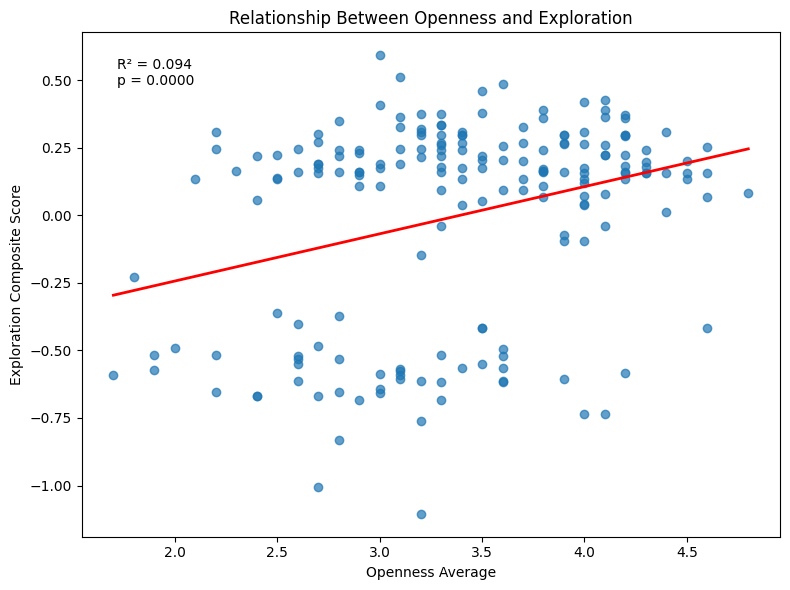

In [124]:


# Make sure both columns are numeric
df["Openness_Average"] = pd.to_numeric(df["Openness_Average"], errors="coerce")
df["Exploration_Composite_Score"] = pd.to_numeric(
    df["Exploration_Composite_Score"], errors="coerce"
)

# Drop missing values
reg_df = df[["Openness_Average", "Exploration_Composite_Score"]].dropna()

# Regression
X = sm.add_constant(reg_df["Openness_Average"])
y = reg_df["Exploration_Composite_Score"]

model = sm.OLS(y, X).fit()

# ==========================================
# NEW: DISPLAY REGRESSION TABLE
# ==========================================
# Option A: Standard full text output
print("=== OLS REGRESSION SUMMARY ===")
print(model.summary())
print("\n" + "=" * 50 + "\n")

# Option B: Clean, APA-style table format using summary2
from statsmodels.iolib.summary2 import summary_col

df_output = summary_col(
    [model],
    stars=True,
    float_format="%.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R-squared": lambda x: f"{x.rsquared:.3f}",
    },
)
df_output.title = "OLS Regression: Predicting Exploration Composite Score"
print(df_output)
# ==========================================

# Predicted regression line
x_vals = np.linspace(
    reg_df["Openness_Average"].min(), reg_df["Openness_Average"].max(), 100
)
X_pred = sm.add_constant(x_vals)
y_pred = model.predict(X_pred)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(
    reg_df["Openness_Average"],
    reg_df["Exploration_Composite_Score"],
    alpha=0.7,
)

plt.plot(x_vals, y_pred, color="red", linewidth=2)  # Added color to distinguish the line

plt.title("Relationship Between Openness and Exploration")
plt.xlabel("Openness Average")
plt.ylabel("Exploration Composite Score")

plt.text(
    0.05,
    0.95,
    f"R² = {model.rsquared:.3f}\np = {model.pvalues['Openness_Average']:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.tight_layout()
plt.show()

In [125]:
# ==========================================
# EXTRACT ALL STATISTICS FOR GOOGLE SHEETS
# ==========================================

# 1. Coefficient-level stats
coef_df = pd.DataFrame({
    'B (Unstandardized)': model.params,
    'SE': model.bse,
    'Beta (Standardized)': model.params * (reg_df["Openness_Average"].std() / reg_df["Exploration_Composite_Score"].std()) if "const" in model.params else 0, # Note: Beta for intercept will be set to 0 below
    't-statistic': model.tvalues,
    'p-value': model.pvalues,
    '95% CI Lower': model.conf_int()[0],
    '95% CI Upper': model.conf_int()[1]
})
# Clean up the standardized beta for the constant intercept
if 'const' in coef_df.index:
    coef_df.at['const', 'Beta (Standardized)'] = np.nan

# 2. Model-level stats
model_stats = {
    'R': np.sqrt(model.rsquared),
    'R²': model.rsquared,
    'Adjusted R²': model.rsquared_adj,
    'F statistic': model.fvalue,
    'df_model (df1)': model.df_model,
    'df_resid (df2)': model.df_resid,
    'Model p-value': model.f_pvalue
}

# 3. Combine into one spreadsheet-ready layout
print("\n--- COPY FROM BELOW THIS LINE ---")
# Print Coefficients first
print(coef_df.to_csv(sep='\t'))

print("\nModel-Level Statistics")
for metric, value in model_stats.items():
    print(f"{metric}\t{value}")
print("--- COPY UP TO THIS LINE ---")


--- COPY FROM BELOW THIS LINE ---
	B (Unstandardized)	SE	Beta (Standardized)	t-statistic	p-value	95% CI Lower	95% CI Upper
const	-0.5928276758417432	0.13689748742921717		-4.330449645018246	2.4235172001348898e-05	-0.862889597689066	-0.3227657539944204
Openness_Average	0.17463284091971554	0.03958423010121809	0.30703134182883235	4.411677086384502	1.7294169058494587e-05	0.09654380176544351	0.25272188007398755


Model-Level Statistics
R	0.30703134182883207
R²	0.09426824486521312
Adjusted R²	0.08942475954363671
F statistic	19.462894714530044
df_model (df1)	1.0
df_resid (df2)	187.0
Model p-value	1.7294169058494682e-05
--- COPY UP TO THIS LINE ---


# Openness x Exploration - moderated by industry

In [126]:
df = df.copy()
print(df["Desired_industry"].head())

industry_reverse_ranking = {
    "1": 20,  # Arts, Entertainment, and Recreation
    "2": 19,  # Information
    "3": 18,  # Professional, Scientific, and Technical Services
    "4": 17,  # Educational Services
    "5": 16,  # Finance and Insurance
    "6": 15,  # Health Care and Social Assistance
    "7": 14,  # Real Estate
    "8": 13,  # Management of Companies
    "9": 12,  # Administrative and Support
    "10": 11,  # Retail Trade
    "11": 10,  # Wholesale Trade
    "12": 9,  # Transportation and Warehousing
    "13": 8,  # Accommodation and Food Services
    "14": 7,  # Manufacturing
    "15": 6,  # Construction
    "16": 5,  # Public Administration
    "17": 4,  # Other Services
    "18": 3,  # Utilities
    "19": 2,  # Agriculture
    "20": 1,  # Mining
}



df["Desired_industry"] = df["Desired_industry"].map(industry_reverse_ranking)
df = df.dropna(subset=["Desired_industry"])
print(df["Desired_industry"].head())


1     16
2     16
3     16
4    NaN
5     16
Name: Desired_industry, dtype: str
1    5.0
2    5.0
3    5.0
5    5.0
6    6.0
Name: Desired_industry, dtype: float64


In [127]:
# ============================================================
# Openness x Industry Ranking Moderation Model
# DV: Exploration_Composite_Score
# IV: Openness_Average
# Moderator: Industry_Ranking
# ============================================================

from statsmodels.iolib.summary2 import summary_col
from scipy import stats

# IMPORTANT:
# Run this from the dataframe AFTER you created:
# - Openness_Average
# - Exploration_Composite_Score
# but BEFORE overwriting Desired_industry with numeric rankings.

analysis_df = df[[
    "Openness_Average",
    "Exploration_Composite_Score",
    "Desired_industry"
]].copy()

# Convert industry response codes safely to string
analysis_df["Desired_industry_code"] = (
    analysis_df["Desired_industry"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

# Higher score = higher-ranked / more desirable / more innovative industry
industry_ranking = {
    "1": 20,  # Arts, Entertainment, and Recreation
    "2": 19,  # Information
    "3": 18,  # Professional, Scientific, and Technical Services
    "4": 17,  # Educational Services
    "5": 16,  # Finance and Insurance
    "6": 15,  # Health Care and Social Assistance
    "7": 14,  # Real Estate
    "8": 13,  # Management of Companies
    "9": 12,  # Administrative and Support
    "10": 11, # Retail Trade
    "11": 10, # Wholesale Trade
    "12": 9,  # Transportation and Warehousing
    "13": 8,  # Accommodation and Food Services
    "14": 7,  # Manufacturing
    "15": 6,  # Construction
    "16": 5,  # Public Administration
    "17": 4,  # Other Services
    "18": 3,  # Utilities
    "19": 2,  # Agriculture
    "20": 1,  # Mining
}

analysis_df["Industry_Ranking"] = analysis_df["Desired_industry_code"].map(industry_ranking)

# Drop missing values for the full moderation model
analysis_df = analysis_df.dropna(subset=[
    "Openness_Average",
    "Exploration_Composite_Score",
    "Industry_Ranking"
]).copy()

# Mean-center predictors before interaction
# This makes the coefficients easier to interpret
analysis_df["Openness_c"] = (
    analysis_df["Openness_Average"] - analysis_df["Openness_Average"].mean()
)

analysis_df["Industry_Ranking_c"] = (
    analysis_df["Industry_Ranking"] - analysis_df["Industry_Ranking"].mean()
)

# Interaction term
analysis_df["Openness_x_Industry"] = (
    analysis_df["Openness_c"] * analysis_df["Industry_Ranking_c"]
)

# ============================================================
# MODEL 1: Baseline model
# Openness predicting exploration
# ============================================================

X_baseline = sm.add_constant(analysis_df[["Openness_c"]])
y = analysis_df["Exploration_Composite_Score"]

model_baseline = sm.OLS(y, X_baseline).fit()

# ============================================================
# MODEL 2: Moderation model
# Openness + industry ranking + interaction
# ============================================================

X_moderation = sm.add_constant(analysis_df[[
    "Openness_c",
    "Industry_Ranking_c",
    "Openness_x_Industry"
]])

model_moderation = sm.OLS(y, X_moderation).fit()

# ============================================================
# Compare models
# ============================================================

print("=== BASELINE MODEL ===")
print(model_baseline.summary())

print("\n\n=== MODERATION MODEL ===")
print(model_moderation.summary())

# Clean side-by-side table
comparison = summary_col(
    [model_baseline, model_moderation],
    model_names=["Baseline", "Moderation"],
    stars=True,
    float_format="%.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R²": lambda x: f"{x.rsquared:.3f}",
        "Adj. R²": lambda x: f"{x.rsquared_adj:.3f}",
    }
)

comparison.title = "Regression Models Predicting Company Exploration"
print(comparison)

# ============================================================
# R² change from baseline to moderation model
# ============================================================

r2_change = model_moderation.rsquared - model_baseline.rsquared
df_change = model_moderation.df_model - model_baseline.df_model
df_resid = model_moderation.df_resid

f_change = (r2_change / df_change) / ((1 - model_moderation.rsquared) / df_resid)
p_change = 1 - stats.f.cdf(f_change, df_change, df_resid)

print("\n=== MODEL COMPARISON ===")
print(f"R² baseline: {model_baseline.rsquared:.3f}")
print(f"R² moderation: {model_moderation.rsquared:.3f}")
print(f"R² change: {r2_change:.3f}")
print(f"F change: {f_change:.3f}")
print(f"p-value for R² change: {p_change:.4f}")

# Key moderation term
print("\n=== KEY INTERACTION TEST ===")
print(f"Interaction coefficient: {model_moderation.params['Openness_x_Industry']:.3f}")
print(f"Interaction p-value: {model_moderation.pvalues['Openness_x_Industry']:.4f}")

=== BASELINE MODEL ===
                                 OLS Regression Results                                
Dep. Variable:     Exploration_Composite_Score   R-squared:                       0.107
Model:                                     OLS   Adj. R-squared:                  0.101
Method:                          Least Squares   F-statistic:                     16.46
Date:                         Fri, 05 Jun 2026   Prob (F-statistic):           8.32e-05
Time:                                 15:44:23   Log-Likelihood:                -51.556
No. Observations:                          139   AIC:                             107.1
Df Residuals:                              137   BIC:                             113.0
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------

# T-Test

In [128]:
duplicate_cols = df.columns[df.columns.duplicated()]
duplicate_cols

comp_b_duplicates = df.loc[:, df.columns == "Comp_B_Explor_Explor"]

comp_b_duplicates.head()

,Comp_B_Explor_Explor
1,3
2,1
3,4
5,1
6,2


In [130]:
paired_df = pd.DataFrame({
    "Comp_A": df["Comp_A_Explor_Explor"],
    "Comp_B": df["Comp_B_Explor_Explor"]
})

# Convert strings to numbers
paired_df["Comp_A"] = pd.to_numeric(paired_df["Comp_A"], errors="coerce")
paired_df["Comp_B"] = pd.to_numeric(paired_df["Comp_B"], errors="coerce")

# Drop rows where either A or B is missing
paired_df = paired_df.dropna()

# Paired t-test
t_stat, p_value = stats.ttest_rel(
    paired_df["Comp_A"],
    paired_df["Comp_B"]
)

print(f"t = {t_stat:.3f}, p = {p_value:.3f}")
print(paired_df.describe())


t = 19.138, p = 0.000
           Comp_A      Comp_B
count  139.000000  139.000000
mean     5.863309    1.877698
std      1.673326    1.375039
min      1.000000    1.000000
25%      5.000000    1.000000
50%      7.000000    1.000000
75%      7.000000    2.000000
max      7.000000    7.000000
